In [2]:
# Environment setup and data import
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.io as pio
import os
import joblib

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
from sklearn.model_selection import KFold, StratifiedKFold, RepeatedStratifiedKFold, cross_val_score


In [3]:
# Set Plotly template for clean academic styling
pio.templates.default = "plotly_white"

# Load Pima Indians Diabetes dataset directly from a public repository
url = "https://raw.githubusercontent.com/npradaschnor/Pima-Indians-Diabetes-Dataset/master/diabetes.csv"
df = pd.read_csv(url)
print("Diabetes Data shape:", df.shape)
display(df.head())

Diabetes Data shape: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
# the total count and proportion of diabetic vs. healthy patients
counts = df['Outcome'].value_counts()
pcts = df['Outcome'].value_counts(normalize=True) * 100

print("Quantitative Class Breakdown:")
for outcome, count in counts.items():
    label = "Diabetic" if outcome == 1 else "Healthy"
    print(f" - {label} (Outcome {outcome}): {count} records | {pcts[outcome]:.2f}%")

Quantitative Class Breakdown:
 - Healthy (Outcome 0): 500 records | 65.10%
 - Diabetic (Outcome 1): 268 records | 34.90%


In [6]:
# the average clinical measurements (Glucose, BMI, Age, Insulin) grouped by Outcome
display(df.groupby('Outcome')[['Glucose', 'BMI', 'Age', 'Insulin', 'BloodPressure']].mean())

,Glucose,BMI,Age,Insulin,BloodPressure
Outcome,,,,,
0,109.980000,30.304200,31.190000,68.792000,68.184000
1,141.257463,35.142537,37.067164,100.335821,70.824627


In [7]:
# the 10 oldest patients in the dataset. Are they mostly diabetic or healthy
oldest_patients = df.sort_values(by='Age', ascending=False).head(10)
display(oldest_patients[['Age', 'Glucose', 'BMI', 'Outcome']])

,Age,Glucose,BMI,Outcome
459,81,134,25.9,0
453,72,119,19.6,0
666,70,145,32.5,1
123,69,132,26.8,0
684,69,136,0.0,0
674,68,91,35.6,0
363,67,146,38.5,1
489,67,194,26.1,0
537,67,57,21.7,0
495,66,166,26.6,0


In [8]:
# Filter all patients with a BMI greater than 35 and Age greater than 50 and their diabetes rate?
high_risk = df[(df['BMI'] > 35) & (df['Age'] > 50)]
total_high = len(high_risk)
diabetic_high = high_risk['Outcome'].sum()

print(f"Total high-risk patients (BMI > 35 & Age > 50): {total_high}")
print(f"Diabetic patients in this group: {diabetic_high} (Diabetes rate: {(diabetic_high/total_high)*100:.2f}%)")

Total high-risk patients (BMI > 35 & Age > 50): 23
Diabetic patients in this group: 14 (Diabetes rate: 60.87%)


##### Identifying Zeros as Missing Values
In clinical logs, missing values are sometimes recorded as `0` instead of `NaN`. Identify how many zero values exist in key clinical columns where a zero is biologically impossible (Glucose, BloodPressure, SkinThickness, Insulin, and BMI).

In [9]:
impossible_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
print("Count of invalid zero values per column:")
for col in impossible_cols:
    zeros = (df[col] == 0).sum()
    print(f" - {col}: {zeros} zeros ({(zeros / len(df))*100:.2f}% of data)")

Count of invalid zero values per column:
 - Glucose: 5 zeros (0.65% of data)
 - BloodPressure: 35 zeros (4.56% of data)
 - SkinThickness: 227 zeros (29.56% of data)
 - Insulin: 374 zeros (48.70% of data)
 - BMI: 11 zeros (1.43% of data)


In [10]:
# highest correlation with the Outcome target
correlations = df.corr()['Outcome'].drop('Outcome').sort_values(ascending=False)
print("Feature correlations with Outcome:")
print(correlations)

Feature correlations with Outcome:
Glucose                     0.466581
BMI                         0.292695
Age                         0.238356
Pregnancies                 0.221898
DiabetesPedigreeFunction    0.173844
Insulin                     0.130548
SkinThickness               0.074752
BloodPressure               0.065068
Name: Outcome, dtype: float64


In [11]:
### Line Chart: Diabetes Prevalence Trend by Age Group

# Bin Age into groups of 5 years
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=range(20, 90, 5)
)

# Calculate diabetes prevalence (%)
age_group_stats = (
    df.groupby('AgeGroup', observed=False)['Outcome']
      .mean() * 100
)

print(age_group_stats)


AgeGroup
(20, 25]    16.853933
(25, 30]    30.000000
(30, 35]    50.617284
(35, 40]    46.052632
(40, 45]    57.894737
(45, 50]    54.054054
(50, 55]    67.741935
(55, 60]    43.478261
(60, 65]    21.428571
(65, 70]    36.363636
(70, 75]     0.000000
(75, 80]          NaN
(80, 85]     0.000000
Name: Outcome, dtype: float64


In [12]:
fig = px.line(
    x=age_group_stats.index.astype(str),
    y=age_group_stats.values,
    title='Diabetes Prevalence Trend by Age Group',
    labels={
        'x': 'Age Group (5-Year Bins)',
        'y': 'Diabetes Percentage (%)'
    },
    markers=True,
    color_discrete_sequence=['#D84315']
)
fig.show()

In [13]:
### Bar Charts (Vertical & Horizontal): Mean Glucose Levels by Outcome

# Filter out invalid zeros for accurate mean calculation
valid_glucose = df[df['Glucose'] > 0]
mean_glucose = valid_glucose.groupby('Outcome')['Glucose'].mean().reset_index()
mean_glucose['Outcome'] = mean_glucose['Outcome'].astype(str)

# Vertical Bar Chart
fig_v = px.bar(
    mean_glucose, x='Outcome', y='Glucose',
    title='Mean Glucose Level by Outcome (Vertical Bar)',
    color='Outcome', color_discrete_map={'0': '#0288D1', '1': '#D84315'}
)
fig_v.show()

# Horizontal Bar Chart
fig_h = px.bar(
    mean_glucose, y='Outcome', x='Glucose', orientation='h',
    title='Mean Glucose Level by Outcome (Horizontal Bar)',
    color='Outcome', color_discrete_map={'0': '#0288D1', '1': '#D84315'}
)
fig_h.show()

In [14]:
### Histogram: BMI Distribution Comparison
valid_data = df[(df['Glucose'] > 0) & (df['Insulin'] > 0)].copy()
valid_data['Outcome'] = valid_data['Outcome'].astype(str)

fig = px.scatter(
    valid_data, x='Glucose', y='Insulin', color='Outcome',
    title='Insulin vs. Glucose Scatter Plot colored by Outcome',
    color_discrete_map={'0': '#0288D1', '1': '#D84315'}
)
fig.show()

In [15]:
### Pie Chart: Proportions of Patient Outcomes

fig = px.pie(
    df, names='Outcome',
    title='Proportional Distribution of Patient Outcomes',
    hole=0.3, color='Outcome',
    color_discrete_map={0: '#0288D1', 1: '#D84315'}
)
fig.show()

In [16]:
### Box Plot: Range Comparison of Insulin Levels

valid_insulin = df[df['Insulin'] > 0].copy()
valid_insulin['Outcome'] = valid_insulin['Outcome'].astype(str)

fig = px.box(
    valid_insulin, x='Outcome', y='Insulin', color='Outcome',
    title='Outliers Analysis on Insulin Levels by Outcome Class',
    color_discrete_map={'0': '#0288D1', '1': '#D84315'}
)
fig.show()

In [17]:
### Countplot: Visualizing Outcome Classes
fig = px.histogram(
    df, x='Outcome', color='Outcome',
    title='Outcome Class Distributions',
    color_discrete_sequence=px.colors.qualitative.Set2
)
fig.show()

In [18]:
### Barplot: Mean Insulin Level by Age Group
valid_ins = df[df['Insulin'] > 0].copy()
valid_ins['AgeGroup'] = valid_ins['AgeGroup'].astype(str)
mean_ins_age = valid_ins.groupby('AgeGroup')['Insulin'].mean().reset_index()

fig = px.bar(
    mean_ins_age, x='AgeGroup', y='Insulin',
    title='Mean Insulin Level by Age Group',
    color_discrete_sequence=['#0288D1']
)
fig.show()

In [19]:
### Histplot with KDE (Plotly Density Count)
fig = px.histogram(
    df[df['Glucose'] > 0], x='Glucose', color='Outcome',
    marginal='rug', barmode='group',
    title='Glucose Level Distribution Grouped by Outcome',
    color_discrete_sequence=['#0288D1', '#D84315']
)
fig.show()

In [20]:
### Pairplot: Multi-variable Scatter Matrix
features_to_plot = ['Glucose', 'BMI', 'Age', 'Insulin', 'Outcome']
df_pair = df[df['Insulin'] > 0][features_to_plot].copy()
df_pair['Outcome'] = df_pair['Outcome'].astype(str)

fig = px.scatter_matrix(
    df_pair, dimensions=['Glucose', 'BMI', 'Age', 'Insulin'], color='Outcome',
    title='Pairwise Interactions of Primary Clinical Indicators',
    color_discrete_map={'0': '#0288D1', '1': '#D84315'}
)
fig.show()

In [21]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome', 'AgeGroup'],
      dtype='str')

In [22]:
len(df[df['Glucose']==0])

5

#### Data Leakage Protection & Train-Test Splits
To prevent **Data Leakage**, we partition our dataset into training and test sets *before* performing any imputation or scaling.

First, we remove the hourly visual helper column (`AgeGroup`) and map invalid `0` values to `NaN` so our Scikit-Learn `SimpleImputer` can catch them cleanly during the pipeline.

In [23]:
# Drop visual helper column and separate targets
X = df.drop(columns=['Outcome', 'AgeGroup'])
y = df['Outcome']

# Replace biologically impossible zeros with NaN
impossible_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
X[impossible_cols] = X[impossible_cols].replace(0, np.nan)

# Stratified Train-Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=1, stratify=y
)

print("Training Set Features Shape:", X_train.shape)
print("Testing Set Features Shape:", X_test.shape)
print("\nNull values present in training split after NaN replacement:")
print(X_train.isnull().sum())

Training Set Features Shape: (614, 8)
Testing Set Features Shape: (154, 8)

Null values present in training split after NaN replacement:
Pregnancies                   0
Glucose                       3
BloodPressure                24
SkinThickness               175
Insulin                     292
BMI                           7
DiabetesPedigreeFunction      0
Age                           0
dtype: int64


#### Modular Preprocessing Pipeline
We build a pipeline utilizing `SimpleImputer` with a `'median'` strategy to impute missing NaNs safely, followed by a `StandardScaler` to normalize features.

In [24]:
preprocessor = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Fit preprocessor strictly on training data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Preprocessed training features shape:", X_train_processed.shape)
print("Confirming zero null values remain:", np.isnan(X_train_processed).sum())

Preprocessed training features shape: (614, 8)
Confirming zero null values remain: 0


In [25]:
## Data Sampling Bias Assessment
# 1. Class Distribution Stratification Check
train_pct = y_train.value_counts(normalize=True) * 100
test_pct = y_test.value_counts(normalize=True) * 100
orig_pct = y.value_counts(normalize=True) * 100

bias_class_df = pd.DataFrame({
    'Original Dataset (%)': orig_pct,
    'Training Split (%)': train_pct,
    'Testing Split (%)': test_pct
})
print("=== Class Stratification Bias Audit ===")
display(bias_class_df)

# 2. Feature Distribution Audit (Checking for Selection Bias)
train_means = X_train.mean()
test_means = X_test.mean()
train_stds = X_train.std()
test_stds = X_test.std()

bias_feature_df = pd.DataFrame({
    'Train Mean': train_means,
    'Test Mean': test_means,
    'Train Std': train_stds,
    'Test Std': test_stds,
    'Abs Mean Difference': (train_means - test_means).abs()
})
print("\n=== Feature Distribution Bias Audit (Train vs. Test) ===")
display(bias_feature_df)

=== Class Stratification Bias Audit ===


,Original Dataset (%),Training Split (%),Testing Split (%)
Outcome,,,
0,65.104167,65.14658,64.935065
1,34.895833,34.85342,35.064935



=== Feature Distribution Bias Audit (Train vs. Test) ===


,Train Mean,Test Mean,Train Std,Test Std,Abs Mean Difference
Pregnancies,3.859935,3.785714,3.401361,3.249865,0.074221
Glucose,122.076923,120.118421,30.620452,30.241617,1.958502
BloodPressure,72.311864,72.790210,12.011216,13.847181,0.478345
SkinThickness,29.218679,28.872549,10.540962,10.243251,0.346130
Insulin,150.891304,176.375000,108.277352,156.669333,25.483696
BMI,32.530313,32.162667,6.961239,6.791235,0.367646
DiabetesPedigreeFunction,0.475322,0.458136,0.332734,0.326373,0.017186
Age,33.151466,33.597403,11.649511,12.224223,0.445937


In [27]:
#### Baseline Model Building (Train-Test Validation)

# Compute class scale weight for XGBoost
scale_pos_weight = (len(y_train) - sum(y_train)) / sum(y_train)

# Initialize the 8 classifiers
models = {
    "Logistic Regression": LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "Support Vector Machine": SVC(probability=True, class_weight='balanced', random_state=42),
    "Decision Tree": DecisionTreeClassifier(class_weight='balanced', random_state=42),
    "Random Forest": RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42),
    "XGBoost": XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42, n_jobs=-1)
}

baseline_results = {}

for name, model in models.items():
    # Train model
    model.fit(X_train_processed, y_train)

    # Predict on train and test
    y_train_pred = model.predict(X_train_processed)
    y_test_pred = model.predict(X_test_processed)
    y_pred_prob = model.predict_proba(X_test_processed)[:, 1]

    # F1 scores for diagnostics
    train_f1 = f1_score(y_train, y_train_pred)
    test_f1 = f1_score(y_test, y_test_pred)
    gap = train_f1 - test_f1

    # Fit status rules
    if train_f1 < 0.60 and test_f1 < 0.60:
        fit_status = 'Underfitting'
    elif gap > 0.12:
        fit_status = 'Overfitting'
    else:
        fit_status = 'Balanced'

    # Save metrics
    baseline_results[name] = {
        "Train F1": train_f1,
        "Test F1": test_f1,
        "F1 Gap": gap,
        "Fit Status": fit_status,
        "Accuracy": accuracy_score(y_test, y_test_pred),
        "Precision": precision_score(y_test, y_test_pred),
        "Recall": recall_score(y_test, y_test_pred),
        "ROC-AUC": roc_auc_score(y_test, y_pred_prob)
    }

baseline_df = pd.DataFrame(baseline_results).T.sort_values(by="Test F1", ascending=False)
print("=== Baseline Models (Diagnostics & Fit Status) ===")
display(baseline_df)

/Users/nishanmahato/Desktop/untitled folder/venv/lib/python3.13/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


=== Baseline Models (Diagnostics & Fit Status) ===


,Train F1,Test F1,F1 Gap,Fit Status,Accuracy,Precision,Recall,ROC-AUC
Logistic Regression,0.68709,0.654545,0.032544,Balanced,0.753247,0.642857,0.666667,0.828704
Support Vector Machine,0.767296,0.65,0.117296,Balanced,0.727273,0.590909,0.722222,0.817222
Decision Tree,1.0,0.626263,0.373737,Overfitting,0.75974,0.688889,0.574074,0.717037
Gradient Boosting,0.886747,0.62,0.266747,Overfitting,0.753247,0.673913,0.574074,0.829074
Random Forest,1.0,0.619469,0.380531,Overfitting,0.720779,0.59322,0.648148,0.81463
XGBoost,1.0,0.618182,0.381818,Overfitting,0.727273,0.607143,0.62963,0.771481
AdaBoost,0.687651,0.601942,0.08571,Balanced,0.733766,0.632653,0.574074,0.793333
K-Nearest Neighbors,0.748792,0.574257,0.174535,Overfitting,0.720779,0.617021,0.537037,0.802037


In [28]:
# Validation Strategy Analysis (K-Fold vs. Stratified K-Fold vs. Repeated Stratified K-Fold)

# Define cross validation splitting strategies
kfold = KFold(n_splits=5, shuffle=True, random_state=42)
skfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rep_skfold = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)

cv_comparison = {}

for name, model in models.items():
    # 1. K-Fold CV
    kf_scores = cross_val_score(model, X_train_processed, y_train, cv=kfold, scoring='f1', n_jobs=-1)

    # 2. Stratified K-Fold CV
    skf_scores = cross_val_score(model, X_train_processed, y_train, cv=skfold, scoring='f1', n_jobs=-1)

    # 3. Repeated Stratified K-Fold CV
    rep_skf_scores = cross_val_score(model, X_train_processed, y_train, cv=rep_skfold, scoring='f1', n_jobs=-1)

    # Store results
    cv_comparison[name] = {
        "K-Fold Mean F1": kf_scores.mean(),
        "K-Fold F1 Std": kf_scores.std(),
        "Stratified K-Fold Mean F1": skf_scores.mean(),
        "Stratified K-Fold F1 Std": skf_scores.std(),
        "Repeated Stratified Mean F1": rep_skf_scores.mean(),
        "Repeated Stratified F1 Std": rep_skf_scores.std()
    }

cv_df = pd.DataFrame(cv_comparison).T.sort_values(by="Stratified K-Fold Mean F1", ascending=False)
print("=== Cross-Validation Strategies Performance Comparison (F1-Score) ===")
display(cv_df)

/Users/nishanmahato/Desktop/untitled folder/venv/lib/python3.13/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/nishanmahato/Desktop/untitled folder/venv/lib/python3.13/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/nishanmahato/Desktop/untitled folder/venv/lib/python3.13/site-packages/sklearn/svm/_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
/Users/nishanmahato/Desktop/untitled folder/venv/lib/python3.13/site-p

=== Cross-Validation Strategies Performance Comparison (F1-Score) ===


,K-Fold Mean F1,K-Fold F1 Std,Stratified K-Fold Mean F1,Stratified K-Fold F1 Std,Repeated Stratified Mean F1,Repeated Stratified F1 Std
Logistic Regression,0.678214,0.039278,0.689426,0.052684,0.682874,0.059283
Support Vector Machine,0.692740,0.045715,0.687666,0.057370,0.687551,0.054568
Random Forest,0.667367,0.030065,0.677179,0.068528,0.681628,0.059724
AdaBoost,0.623411,0.046391,0.652616,0.081145,0.636764,0.076576
XGBoost,0.675681,0.021619,0.642292,0.060187,0.632641,0.055950
Gradient Boosting,0.604169,0.038932,0.633139,0.105867,0.623625,0.076644
K-Nearest Neighbors,0.625962,0.048801,0.622553,0.049677,0.615779,0.052617
Decision Tree,0.561082,0.074545,0.577848,0.075305,0.562539,0.065862


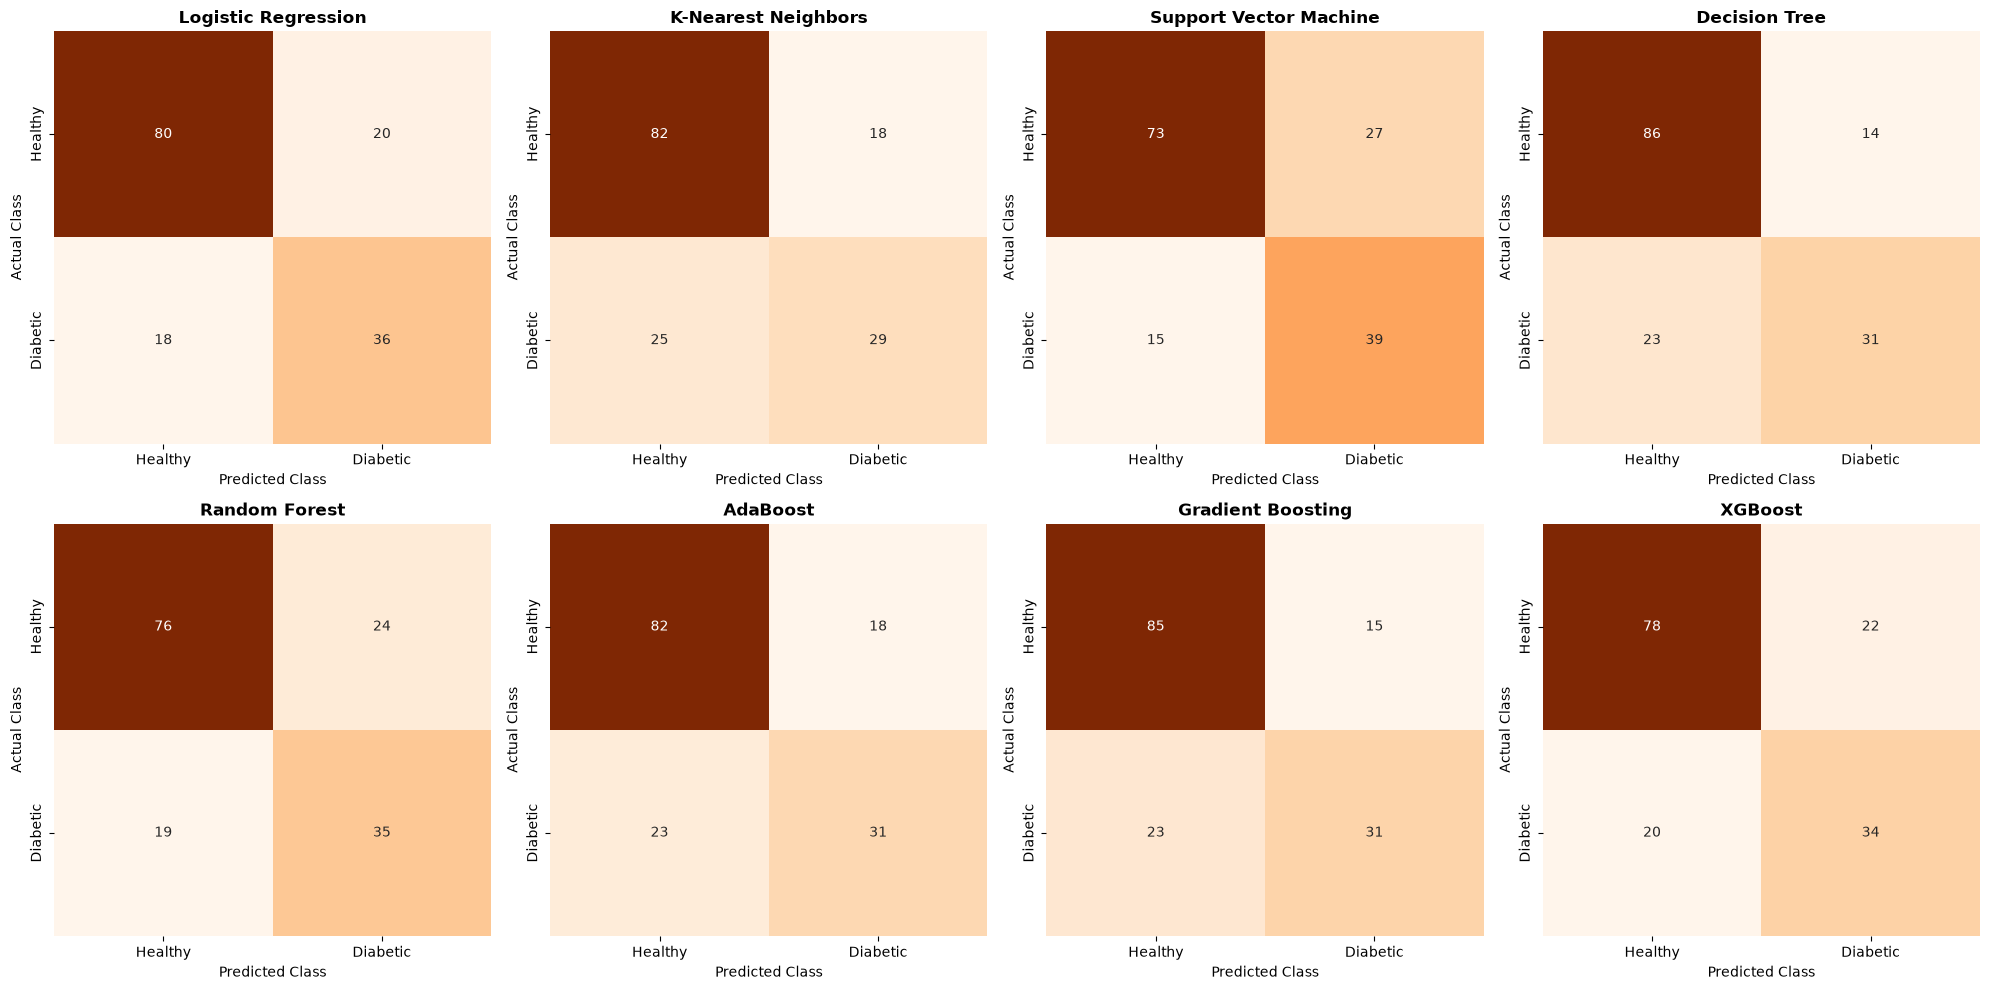

In [29]:
# Confusion Matrices Grid (Row-Wise Layout)
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for idx, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test_processed)
    cm = confusion_matrix(y_test, y_pred)

    sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', cbar=False, ax=axes[idx],
                xticklabels=['Healthy', 'Diabetic'], yticklabels=['Healthy', 'Diabetic'])
    axes[idx].set_title(name, fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Actual Class')
    axes[idx].set_xlabel('Predicted Class')

plt.tight_layout()
plt.show()

In [30]:
# Model Hyperparameter Tuning
param_dist = {
    'n_estimators': [50, 100, 150],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.05, 0.1, 0.2],
    'subsample': [0.8, 1.0]
}

random_search = RandomizedSearchCV(
    XGBClassifier(scale_pos_weight=scale_pos_weight, random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=8,
    scoring='f1',
    cv=3,
    random_state=42,
    n_jobs=-1
)
random_search.fit(X_train_processed, y_train)
best_model = random_search.best_estimator_

print("Best Hyperparameters Found:", random_search.best_params_)
y_tuned_pred = best_model.predict(X_test_processed)
print("Tuned Model Classification Report:")
print(classification_report(y_test, y_tuned_pred))

Best Hyperparameters Found: {'subsample': 0.8, 'n_estimators': 50, 'max_depth': 3, 'learning_rate': 0.05}
Tuned Model Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.74      0.80       100
           1       0.62      0.78      0.69        54

    accuracy                           0.75       154
   macro avg       0.74      0.76      0.74       154
weighted avg       0.78      0.75      0.76       154



In [32]:
#### Serialization & Export

# Create artifact directory if it does not exist
os.makedirs('artifact', exist_ok=True)

# Create full inference pipeline
full_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', best_model)
])

# Export files
joblib.dump(full_pipeline, 'artifact/best_diabetes_model.pkl')
print("Full model pipeline successfully saved as best_diabetes_model.pkl!")

Full model pipeline successfully saved as best_diabetes_model.pkl!
